In [1]:
### Parte I:

In [2]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Directorio Lucas:

#os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\New folder")

# Directorio Mateo:
os.chdir(r"C:\Users\User\Downloads\E337_Grupo2-main\E337_Grupo2-main\TP2")

In [4]:
### Ejercicio 1:

# Para este ejercicio, necesitamos traer la base de datos "limpiada" del trabajo práctico anterior. Esto lo hicimos usando .to_parquet para descargar las bases como dta

df = pd.read_parquet("base_con_informal")

In [5]:
df.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO'],
      dtype='object')

In [6]:
# Recordemos que la variable CH06 encapsula lo referido a las edades de los encuestados. Por lo que la utilizamos para crear "edad2"

df['edad2'] = df['CH06'] ** 2

In [7]:
df.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2'],
      dtype='object')

In [8]:
# Realicemos los graficos pedidoos

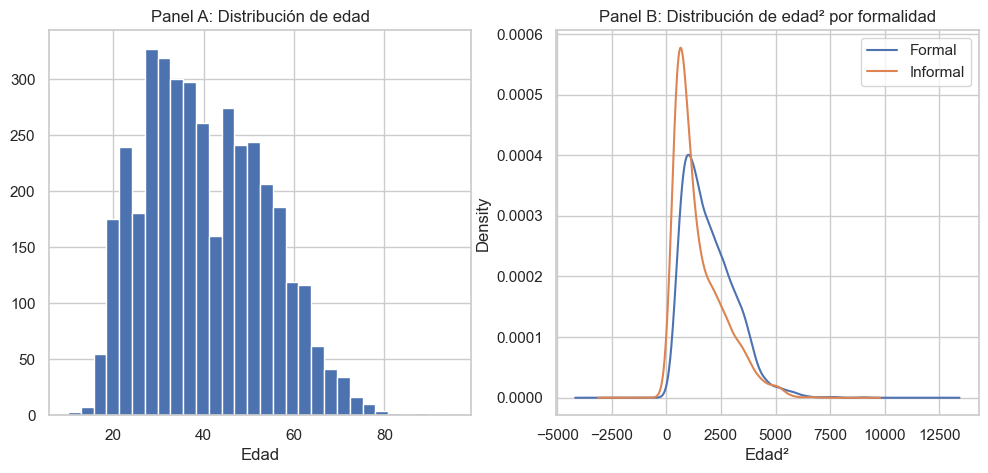

In [9]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Hagamos el histograma para la variable edad

axs[0].hist(df['CH06'].dropna(), bins=30)
axs[0].set_title('Panel A: Distribución de edad')
axs[0].set_xlabel('Edad')

# Ahora construyamos el segundo panel

formales = df[df['informal'] == 0]['edad2'].dropna()
informales = df[df['informal'] == 1]['edad2'].dropna()

formales.plot.kde(ax=axs[1], label='Formal')
informales.plot.kde(ax=axs[1], label='Informal')

axs[1].set_title('Panel B: Distribución de edad² por formalidad')
axs[1].set_xlabel('Edad²')
axs[1].legend()

In [10]:
### Ejercicio 2:

In [11]:
# Empecemos a creear la variable educ, mediante las variables que ya tenemos de las bases de datos previamente guardadas. 
# Para ello usemos for para determinar que se guarda dentro

In [12]:
# Vamos a necesitar traer esas variables dado a que no las tenemos dentro de nuestros dataframes,
# para ello sigamos el mismo proceso que utilizamos en el tp1

df1 = pd.read_excel('usu_individual_T325.xlsx')
df2 = pd.read_stata('individual_t305.dta', convert_categoricals=False)

# Homogeneizamos nombres
df2.columns = df2.columns.str.upper()

# Filtramos región de Cuyo (42) en ambas
df1 = df1[df1["REGION"] == 42]
df2 = df2[df2["REGION"] == 42]

# Agregamos variable de año
df1["AÑO"] = 2025
df2["AÑO"] = 2005

# Convertimos las columnas que están en un formato incorrecto en df2 a numérico
formato_incorrecto = [
    'CH14', 'CH15_COD', 'CH16_COD', 'PP04B_COD', 'PP04D_COD', 'PP11B_COD',
    'PP11D_COD', 'DECOCUR', 'IDECOCUR', 'RDECOCUR', 'GDECOCUR', 'PDECOCUR',
    'ADECOCUR', 'DECINDR', 'IDECINDR', 'RDECINDR', 'GDECINDR', 'PDECINDR',
    'ADECINDR', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR',
    'ADECIFR', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR'
]

for col in formato_incorrecto:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')

# Merge vertical
df_original = pd.concat([df1, df2], ignore_index=True)
df_original2 = df_original.copy()

# Nos quedamos con las variables de interés, incluyendo CH12, CH13 y CH14
columnas_interes = ['AÑO','CH12', 'CH13', 'CH14']

df_original = df_original[columnas_interes]

In [13]:
df_original.head()

,AÑO,CH12,CH13,CH14
0,2025,2.0,2.0,2.0
1,2025,0.0,0.0,NaN
2,2025,2.0,2.0,2.0
3,2025,4.0,1.0,NaN
4,2025,9.0,2.0,98.0


In [14]:
# Creemos ahora la variable educ dentro del dataframe

df_original['educ'] = np.nan

In [15]:
df_original.columns

Index(['AÑO', 'CH12', 'CH13', 'CH14', 'educ'], dtype='object')

In [16]:
# 1) Jardín / preescolar
# Lo más razonable es asignar 0 años de educación formal completa
df_original.loc[df_original['CH12'] == 1, 'educ'] = 0

In [17]:
# 2) Primario incompleto
df_original.loc[(df_original['CH12'] == 2) & (df_original['CH13'] == 2), 'educ'] = df_original['CH14']

# 3) Primario completo
df_original.loc[(df_original['CH12'] == 2) & (df_original['CH13'] == 1), 'educ'] = 6

In [18]:
# 4) EGB
# EGB se puede interpretar como hasta 9 años
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = df_original['CH14']
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 1), 'educ'] = 9

In [19]:
# 5) Secundario incompleto
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 2), 'educ'] = 6 + df_original['CH14']

# 6) Secundario completo
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 1), 'educ'] = 12

In [20]:
# 7) Polimodal
# Polimodal completo equivale a secundario completo
# como dura 3 años después de EGB, incompleto = 9 + año aprobado
df_original.loc[(df_original['CH12'] == 5) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 3)), 'educ'] = 9 + df_original['CH14']
df_original.loc[(df_original['CH12'] == 5) & (df_original['CH13'] == 1), 'educ'] = 12

In [21]:
# 8) Terciario
# incompleto: 12 + año aprobado
df_original.loc[(df_original['CH12'] == 6) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 12 + df_original['CH14']

# completo: asumimos 3 años
df_original.loc[(df_original['CH12'] == 6) & (df_original['CH13'] == 1), 'educ'] = 15

In [22]:
# 8) Universitario
df_original.loc[(df_original['CH12'] == 7) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 12 + df_original['CH14']

# completo: asumimos 5 años
df_original.loc[(df_original['CH12'] == 7) & (df_original['CH13'] == 1), 'educ'] = 17


In [23]:
# 9) Posgrado
df_original.loc[(df_original['CH12'] == 8) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 17 + df_original['CH14']
df_original.loc[(df_original['CH12'] == 8) & (df_original['CH13'] == 1), 'educ'] = 19

In [24]:
# 10) Educación especial -> mejor dejar missing
df_original.loc[df_original['CH12'] == 9, 'educ'] = np.nan

In [25]:
df_original

,AÑO,CH12,CH13,CH14,educ
0,2025,2.0,2.0,2.0,2.0
1,2025,0.0,0.0,NaN,NaN
2,2025,2.0,2.0,2.0,2.0
3,2025,4.0,1.0,NaN,NaN
4,2025,9.0,2.0,98.0,NaN
...,...,...,...,...,...
9259,2005,4.0,2.0,3.0,NaN
9260,2005,3.0,2.0,1.0,7.0
9261,2005,1.0,2.0,0.0,0.0
9262,2005,0.0,0.0,NaN,NaN


In [26]:
# Hagamos entonces la estadistica descriptiva que nos estan pidiendo para esta variable:

In [27]:
df_original['educ'].describe()

count    5655.000000
mean        9.571883
std         6.991942
min         0.000000
25%         6.000000
50%         9.000000
75%        14.000000
max        99.000000
Name: educ, dtype: float64

In [28]:
### Ejercicio 3:

In [29]:
# Veamos a la variable que necesitamos actualizar

df_original2['ITF']

0       1252000.0
1       1252000.0
2       1252000.0
3       1252000.0
4       1252000.0
          ...    
9259        750.0
9260        750.0
9261        750.0
9262        750.0
9263        750.0
Name: ITF, Length: 9264, dtype: float64

In [30]:
# Creemos una variable con el nomnbre que nos pide

df_original2['ingreso_total_familiar'] = df_original2['ITF']

In [31]:
# Necesitamos un factor de inflación para poder actualizar los datos. 
# Para ello usamos la calculadora de inflación para ver cuanto valdría un peso en enero de 2005 en enero de 2025.
# Usando la página dada de "https://calculadoradeinflacion.com/argentina.html?md=enero&ad=2005&mh=enero&ah=2025&q=1&s=cpi"
# podemos ver que 1$ en 2005 equivaldria hoy $949.04, por lo que este sera nuestro factor.

factor = 949.04

df_original2.loc[df_original2['ANO4'] == 2005, 'ingreso_total_familiar'] *= factor

df_original2['ingreso_total_familiar']

0       1252000.0
1       1252000.0
2       1252000.0
3       1252000.0
4       1252000.0
          ...    
9259     711780.0
9260     711780.0
9261     711780.0
9262     711780.0
9263     711780.0
Name: ingreso_total_familiar, Length: 9264, dtype: float64

In [32]:
df_original2

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,AÑO,V2_M,V5_M,V11_M,V21_M,PJ1_1,PJ2_1,PJ3_1,IDIMPP,ingreso_total_familiar
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025.0,3.0,1.0,8.0,0.0,42.0,S,27.0,528.0,...,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252000.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025.0,3.0,1.0,9.0,0.0,42.0,S,27.0,528.0,...,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252000.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025.0,3.0,1.0,1.0,1.0,42.0,S,27.0,528.0,...,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252000.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025.0,3.0,1.0,2.0,1.0,42.0,S,27.0,528.0,...,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252000.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025.0,3.0,1.0,3.0,1.0,42.0,S,27.0,528.0,...,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9259,287829,2005.0,3.0,1.0,2.0,1.0,42.0,N,27.0,227.0,...,2005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000,711780.0
9260,287829,2005.0,3.0,1.0,3.0,0.0,42.0,N,27.0,227.0,...,2005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000,711780.0
9261,287829,2005.0,3.0,1.0,4.0,0.0,42.0,N,27.0,227.0,...,2005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000,711780.0
9262,287829,2005.0,3.0,1.0,5.0,0.0,42.0,N,27.0,227.0,...,2005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000,711780.0


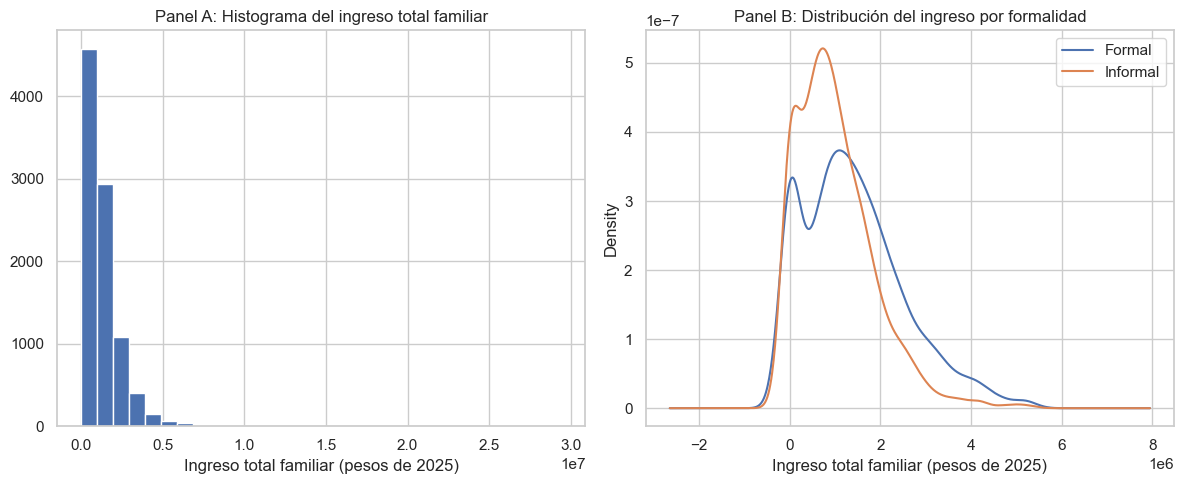

In [33]:
# Construyamos los gráficos pedidos.

sns.set(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Hagamos el histograma ITF

axs[0].hist(df_original2['ingreso_total_familiar'].dropna(), bins=30)
axs[0].set_title('Panel A: Histograma del ingreso total familiar')
axs[0].set_xlabel('Ingreso total familiar (pesos de 2025)')

# Pasemos a construir el segundo panel:
# Acotamos al p99 para evitar que los outliers aplanen el kernel
p99 = df_original2['ingreso_total_familiar'].quantile(0.99)

# Vamos a necesitar también agregar la columna de informal como para hacer el segundo gráfico. 

df_original2['informal'] = df['informal']

formales = df_original2[df_original2['informal'] == 0]['ingreso_total_familiar'].dropna()
informales = df_original2[df_original2['informal'] == 1]['ingreso_total_familiar'].dropna()

formales[formales <= p99].plot.kde(ax=axs[1], label='Formal')
informales[informales <= p99].plot.kde(ax=axs[1], label='Informal')

axs[1].set_title('Panel B: Distribución del ingreso por formalidad')
axs[1].set_xlabel('Ingreso total familiar (pesos de 2025)')
axs[1].legend()

plt.tight_layout()
plt.savefig('grafico_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:
### Ejercicio 4:

In [35]:
# Creemos la variable pedida para este ejercicio

df_original2['horastrab'] = np.nan

# Necesitamos unicamente sumar para el jefe del hogar, teniendo cuidado de las missing values que podemos tener

df_original2.loc[df_original2['CH03'] == 1, 'horastrab'] = (
    df_original2['PP3E_TOT'].fillna(0) + df_original2['PP3F_TOT'].fillna(0)
)

In [36]:
# Realizemos la estadistica descriptiva que nos pide este ejercicio:

In [37]:
df_original2['horastrab'].describe()

count    2829.000000
mean       26.867444
std        24.763273
min         0.000000
25%         0.000000
50%        30.000000
75%        48.000000
max       132.000000
Name: horastrab, dtype: float64

In [38]:
### Ejercicio 5:

In [39]:
### Parte II:

In [40]:
df.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2'],
      dtype='object')

In [41]:
df_original.columns

Index(['AÑO', 'CH12', 'CH13', 'CH14', 'educ'], dtype='object')

In [42]:
df_original2.columns

Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15',
       'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA',
       ...
       'V5_M', 'V11_M', 'V21_M', 'PJ1_1', 'PJ2_1', 'PJ3_1', 'IDIMPP',
       'ingreso_total_familiar', 'informal', 'horastrab'],
      dtype='object', length=247)

In [43]:
# Para homogeneizar un poco todo, pongamos todo lo que hemos construido hasta ahora dentro de df

In [44]:
df['CH12'] = df_original['CH12']
df['CH13'] = df_original['CH13']
df['CH14'] = df_original['CH14']
df['educ'] = df_original['educ']
df['ingreso_total_familiar'] = df_original2['ingreso_total_familiar']
df['horastrab'] = df_original2['horastrab']

In [45]:
df.columns.tolist()

['CH04',
 'CH06',
 'CH07',
 'CH08',
 'NIVEL_ED',
 'ESTADO',
 'CAT_INAC',
 'IPCF',
 'CH14',
 'CH15_COD',
 'CH16_COD',
 'PP03C',
 'PP04B_COD',
 'PP06H',
 'PP07A',
 'AÑO',
 'CAT_OCUP',
 'PP07H',
 'informal',
 'EMPLEO',
 'edad2',
 'CH12',
 'CH13',
 'educ',
 'ingreso_total_familiar',
 'horastrab']

In [46]:
df

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,...,CAT_OCUP,PP07H,informal,EMPLEO,edad2,CH12,CH13,educ,ingreso_total_familiar,horastrab
3,1.0,39.0,1.0,4.0,4.0,1.0,0.0,1.391111e+05,NaN,NaN,...,2.0,0.0,0,2.0,1521.0,4.0,1.0,NaN,1252000.0,NaN
6,1.0,35.0,5.0,1.0,6.0,1.0,0.0,2.500000e+06,NaN,NaN,...,3.0,2.0,1,2.0,1225.0,7.0,1.0,17.0,2500000.0,48.0
7,2.0,46.0,3.0,1.0,6.0,1.0,0.0,1.133333e+06,NaN,NaN,...,3.0,1.0,0,1.0,2116.0,7.0,1.0,17.0,3400000.0,45.0
10,1.0,38.0,2.0,1.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,3.0,1.0,0,1.0,1444.0,4.0,2.0,NaN,0.0,44.0
11,2.0,42.0,2.0,4.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,3.0,2.0,1,2.0,1764.0,4.0,2.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9247,1.0,53.0,5.0,1.0,2.0,1.0,0.0,3.800000e+02,NaN,NaN,...,3.0,1.0,0,NaN,2809.0,2.0,1.0,6.0,1081905.6,NaN
9249,1.0,52.0,2.0,4.0,2.0,1.0,0.0,1.533333e+02,NaN,NaN,...,3.0,2.0,1,NaN,2704.0,2.0,1.0,6.0,436558.4,114.0
9256,2.0,38.0,3.0,12.0,6.0,1.0,0.0,2.500000e+02,NaN,NaN,...,3.0,1.0,0,NaN,1444.0,6.0,1.0,15.0,474520.0,49.0
9258,1.0,28.0,2.0,4.0,2.0,1.0,0.0,1.250000e+02,NaN,NaN,...,2.0,0.0,0,NaN,784.0,2.0,1.0,6.0,711780.0,4.0


In [47]:
# Como nos falta únicamente las variables de 2005=IX_TOT y 2025=IX_Tot, tenemos que construirlas para hacer el resto de ejercicios.

In [48]:
# Paso 1: construir ix_tot en df_original2 (base completa)
df_original2['ix_tot'] = df_original2.groupby(
    ['CODUSU', 'NRO_HOGAR']
)['COMPONENTE'].transform('count')

# Verificación rápida
print(df_original2['ix_tot'].describe())
print(df_original2['ix_tot'].value_counts().head(10))

count    9264.000000
mean        4.307211
std         2.032333
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: ix_tot, dtype: float64
ix_tot
4     2136
3     1599
5     1595
2     1282
6      972
1      491
7      490
8      304
9      216
10     100
Name: count, dtype: int64


In [49]:
# Paso 2: pasar ix_tot a df (que es la base de ocupados)

df['ix_tot'] = df_original2.loc[df.index, 'ix_tot'].values

# Verificación
print(df['ix_tot'].describe())

count    3882.000000
mean        4.014426
std         1.886853
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: ix_tot, dtype: float64


In [50]:
df 

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,...,PP07H,informal,EMPLEO,edad2,CH12,CH13,educ,ingreso_total_familiar,horastrab,ix_tot
3,1.0,39.0,1.0,4.0,4.0,1.0,0.0,1.391111e+05,NaN,NaN,...,0.0,0,2.0,1521.0,4.0,1.0,NaN,1252000.0,NaN,9
6,1.0,35.0,5.0,1.0,6.0,1.0,0.0,2.500000e+06,NaN,NaN,...,2.0,1,2.0,1225.0,7.0,1.0,17.0,2500000.0,48.0,1
7,2.0,46.0,3.0,1.0,6.0,1.0,0.0,1.133333e+06,NaN,NaN,...,1.0,0,1.0,2116.0,7.0,1.0,17.0,3400000.0,45.0,3
10,1.0,38.0,2.0,1.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,1.0,0,1.0,1444.0,4.0,2.0,NaN,0.0,44.0,10
11,2.0,42.0,2.0,4.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,2.0,1,2.0,1764.0,4.0,2.0,NaN,0.0,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9247,1.0,53.0,5.0,1.0,2.0,1.0,0.0,3.800000e+02,NaN,NaN,...,1.0,0,NaN,2809.0,2.0,1.0,6.0,1081905.6,NaN,3
9249,1.0,52.0,2.0,4.0,2.0,1.0,0.0,1.533333e+02,NaN,NaN,...,2.0,1,NaN,2704.0,2.0,1.0,6.0,436558.4,114.0,3
9256,2.0,38.0,3.0,12.0,6.0,1.0,0.0,2.500000e+02,NaN,NaN,...,1.0,0,NaN,1444.0,6.0,1.0,15.0,474520.0,49.0,2
9258,1.0,28.0,2.0,4.0,2.0,1.0,0.0,1.250000e+02,NaN,NaN,...,0.0,0,NaN,784.0,2.0,1.0,6.0,711780.0,4.0,6


In [51]:
df.columns.tolist()

['CH04',
 'CH06',
 'CH07',
 'CH08',
 'NIVEL_ED',
 'ESTADO',
 'CAT_INAC',
 'IPCF',
 'CH14',
 'CH15_COD',
 'CH16_COD',
 'PP03C',
 'PP04B_COD',
 'PP06H',
 'PP07A',
 'AÑO',
 'CAT_OCUP',
 'PP07H',
 'informal',
 'EMPLEO',
 'edad2',
 'CH12',
 'CH13',
 'educ',
 'ingreso_total_familiar',
 'horastrab',
 'ix_tot']

In [52]:
# Ejercicio 2


In [53]:
# ===== REARMADO FINAL PARA PCA =====

# Edad
df['edad'] = df['CH06']

# Variables desde bases originales
df['educ'] = df_original['educ']
df['ingreso_total_familiar'] = df_original2['ingreso_total_familiar']
df['horastrab'] = df_original2['horastrab']

# Miembros del hogar
df_original2['ix_tot'] = df_original2.groupby(['CODUSU', 'NRO_HOGAR'])['COMPONENTE'].transform('count')
df['ix_tot'] = df_original2.loc[df.index, 'ix_tot'].values

# Crear base para PCA
base_p2 = df[['edad', 'edad2', 'educ', 'ingreso_total_familiar', 'ix_tot', 'horastrab']].copy()
base_p2 = base_p2.dropna()

# Chequeo
print(df.columns.tolist())
print(base_p2.shape)

['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H', 'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2', 'CH12', 'CH13', 'educ', 'ingreso_total_familiar', 'horastrab', 'ix_tot', 'edad']
(1092, 6)


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(base_p2)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [55]:
X_pca.shape

(1092, 6)

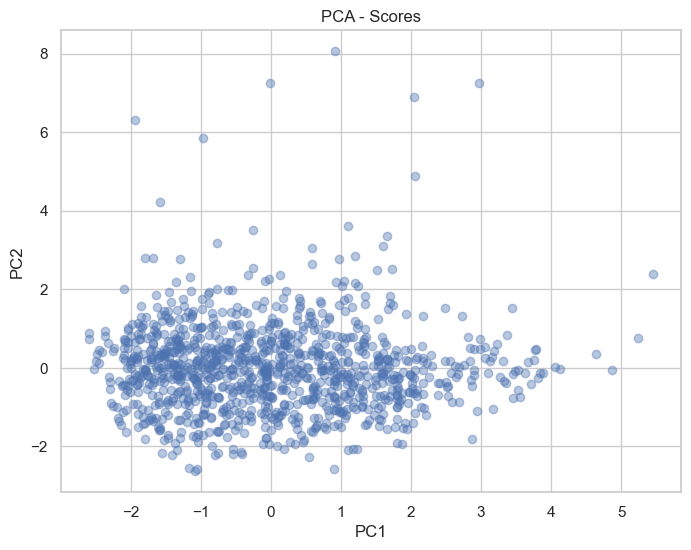

In [58]:
# índices (scores) calculados del primer y segundo componente de PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Scores')
plt.grid(True)

plt.savefig("pca_scores.png", dpi=300, bbox_inches='tight')  # 👈 GUARDAR ACÁ
plt.show()

In [57]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.34524247 0.2106488  0.18513988 0.14563859 0.11154392 0.00178634]
1.0


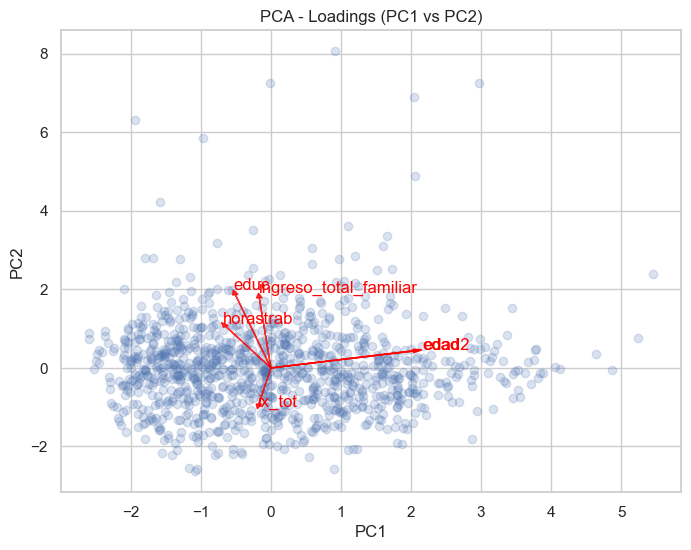

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer loadings
loadings = pca.components_.T

# Crear figura
fig, ax = plt.subplots(figsize=(8,6))

# Scatter de los scores (suave de fondo)
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2)

# Dibujar flechas (loadings)
for i, var in enumerate(base_p2.columns):
    ax.arrow(0, 0, 
             loadings[i, 0]*3, loadings[i, 1]*3,  # escala para que se vean
             color='red', alpha=0.8, head_width=0.08)
    
    ax.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, var, color='red')

# Etiquetas
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA - Loadings (PC1 vs PC2)')
ax.grid(True)

# Guardar figura (IMPORTANTE para Overleaf)
fig.savefig("pca_loadings.png", dpi=300, bbox_inches='tight')

plt.show()

Varianza explicada por componente:
[0.34524247 0.2106488  0.18513988 0.14563859 0.11154392 0.00178634]
Varianza acumulada:
[0.34524247 0.55589127 0.74103115 0.88666974 0.99821366 1.        ]


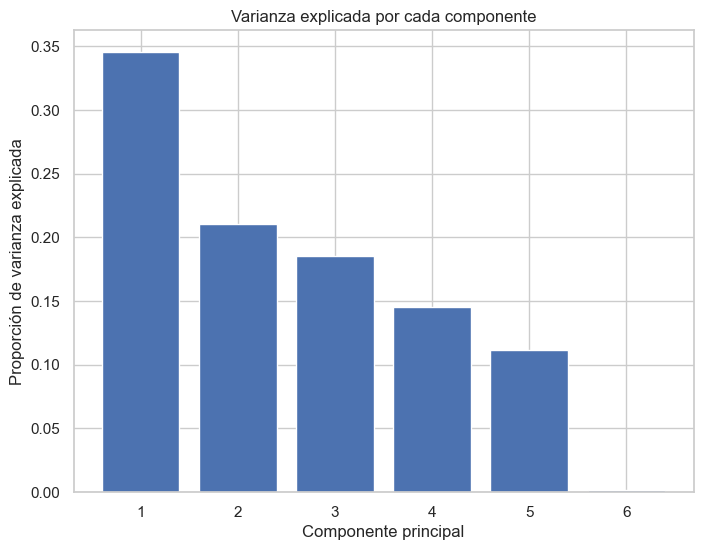

In [60]:
import matplotlib.pyplot as plt
import numpy as np

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

print("Varianza explicada por componente:")
print(explained_var)

print("Varianza acumulada:")
print(cum_explained_var)

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(range(1, len(explained_var)+1), explained_var)
ax.set_xlabel('Componente principal')
ax.set_ylabel('Proporción de varianza explicada')
ax.set_title('Varianza explicada por cada componente')
ax.set_xticks(range(1, len(explained_var)+1))

fig.savefig("pca_varianza.png", dpi=300, bbox_inches='tight')
plt.show()